In [1]:
import pandas as pd
import numpy as np
import math
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import datetime
import warnings
import os
from scipy import stats
import pickle
from dateutil.relativedelta import relativedelta
from scipy.stats import norm, t
import matplotlib as mpl
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

In [2]:
# 0 -- 6 month
# 1 -- 2 year
# 2 -- 5 year
# 3 -- 10 year

rate_reg = 3

In [3]:
load_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Data\Database_Regression.xlsx'
mergedData = pd.read_excel(load_path,index_col=[0],parse_dates=[0])
mergedData = mergedData.loc[datetime(2000,1,1):datetime(2025,1,1),[
    'SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd',
    'SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym',
    'OASd','EASurprise','USSurprise','Uncertainty'
]]
mergedData.dropna(inplace=True)
    
diff_rates_clean = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

z = np.abs(stats.zscore(diff_rates_clean))
threshold = 10

outliers = pd.concat([diff_rates_clean[z.SwapESTR6Md>threshold],diff_rates_clean[z.SwapESTR2Yd>threshold],
                     diff_rates_clean[z.SwapESTR5Yd>threshold],diff_rates_clean[z.SwapESTR10Yd>threshold],
                     diff_rates_clean.loc[datetime(2023,3,13):datetime(2023,3,15)]],axis=0)

outliers.reset_index(inplace=True,drop=False)
outliers.drop_duplicates(subset='Date',inplace=True)
outliers.sort_values(by='Date',inplace=True,ignore_index=True)
outliers.set_index('Date',inplace=True,drop=True)

diff_rates_clean.drop(outliers.index,inplace=True,axis=0)

idx = diff_rates_clean.index

mergedData = mergedData.loc[idx]

In [4]:
ratevol_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']].fillna(method='ffill').rolling(window=5,closed='left').std()
for j in ratevol_estr.columns:
    ratevol_estr.rename(columns={j: j.replace('Yd','Yv')},inplace=True)
    ratevol_estr.rename(columns={j: j.replace('Md','Mv')},inplace=True)

diff_rates_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

df_momentum_estr = mergedData.loc[:,['SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym']]
df_momentum_estr.fillna(method='ffill',inplace=True)

diff_oas = mergedData.loc[:,['OASd']]

df_surprise_ea = mergedData.loc[:,['EASurprise']]
df_surprise_ea = (df_surprise_ea - df_surprise_ea.mean())/df_surprise_ea.std()

df_surprise_us = mergedData.loc[:,['USSurprise']]
df_surprise_us = (df_surprise_us - df_surprise_us.mean())/df_surprise_us.std()

uncertainty = mergedData.loc[:,['Uncertainty']]
uncertainty.columns = ['Uncertainty']

In [5]:
dff_reg = pd.concat([df_surprise_ea,df_surprise_us,df_momentum_estr.iloc[:,rate_reg],ratevol_estr.iloc[:,rate_reg],diff_oas,uncertainty/100],axis=1)
dff_reg.columns = ['EA','US','Momentum','Volatility','OAS','Uncertainty']


X_one = pd.concat([dff_reg.EA,dff_reg.US],axis=1)
X_two = pd.concat([X_one.EA*dff_reg.Uncertainty,
                   X_one.US*dff_reg.Uncertainty],axis=1)
X_two.columns = ['UncertaintyEA','UncertaintyUS']
controls = pd.concat([dff_reg.Momentum,dff_reg.Volatility,dff_reg.OAS,dff_reg.Uncertainty],axis=1)

df_reg = pd.concat([diff_rates_estr.iloc[:,rate_reg],X_one,X_two,controls],axis=1)

Y = df_reg.iloc[:,[0]]
X = df_reg.iloc[:,1:]
X = sm.add_constant(X)
model = sm.OLS(Y, X,missing='drop').fit(cov_type='HAC',cov_kwds={'maxlags':math.ceil(0.75*len(Y)**(1/3))})

z_uncertainty_bar = round(float(dff_reg.Uncertainty.mean()),5)

def g_of_x(matrix):
    return matrix[1,0]/matrix[0,0]
def gradient(matrix):
    return np.matrix([ [-matrix[1,0]/(matrix[0,0]**2)], [1/matrix[0,0]] ])
mu = list()
sigma = list()

### EA Coeficients
beta_hat = [model.params['EA'],model.params['UncertaintyEA']]
sigma_ols = np.matrix(model.cov_params().loc[['EA','UncertaintyEA'],['EA','UncertaintyEA']])
cov_mul = np.matrix([
    [1,z_uncertainty_bar],
    [z_uncertainty_bar,z_uncertainty_bar**2]
])

mu_beta = beta_hat[0] + z_uncertainty_bar*beta_hat[1]
sigma_beta = np.asarray(np.multiply(sigma_ols,cov_mul)).reshape(-1).sum()

for i in range(0,2):
    cov_beta = sigma_ols[i,0] + z_uncertainty_bar*sigma_ols[i,1]
    x_sigma = np.matrix([ [sigma_beta,cov_beta], [cov_beta,sigma_ols[i,i]] ])
    x_mu = np.matrix([ [mu_beta], [beta_hat[i]] ])
    mu.append(g_of_x(x_mu))
    sigma.append(np.asarray(np.matmul(np.matmul(gradient(x_mu).transpose(),x_sigma),gradient(x_mu))).reshape(-1))
mu.append(mu_beta)
sigma.append(sigma_beta)

pvalue_ea = list()
for i in range(0,3):
    pvalue_ea.append(float(1 - norm.cdf(abs(mu[i]/np.sqrt(sigma[i])))))

### US Coefficients
beta_hat = [model.params['US'],model.params['UncertaintyUS']]
sigma_ols = np.matrix(model.cov_params().loc[['US','UncertaintyUS'],['US','UncertaintyUS']])
cov_mul = np.matrix([
    [1,z_uncertainty_bar],
    [z_uncertainty_bar,z_uncertainty_bar**2]
])

mu_beta = beta_hat[0] + z_uncertainty_bar*beta_hat[1]
sigma_beta = np.asarray(np.multiply(sigma_ols,cov_mul)).reshape(-1).sum()
for i in range(0,2):
    cov_beta = sigma_ols[i,0] + z_uncertainty_bar*sigma_ols[i,1]
    x_sigma = np.matrix([ [sigma_beta,cov_beta], [cov_beta,sigma_ols[i,i]] ])
    x_mu = np.matrix([ [mu_beta], [beta_hat[i]] ])
    mu.append(g_of_x(x_mu))
    sigma.append(np.asarray(np.matmul(np.matmul(gradient(x_mu).transpose(),x_sigma),gradient(x_mu))).reshape(-1))
mu.append(mu_beta)
sigma.append(sigma_beta)

pvalue_us = list()
for i in range(3,6):
    pvalue_us.append(float(max(0,1 - norm.cdf(abs(mu[i]/np.sqrt(sigma[i]))))))

df_params = pd.DataFrame(data={'Estimate':(mu),'P-value':(pvalue_ea+pvalue_us)},
             index=[r'$\theta^{EA}$',r'$\phi_1^{EA}$',r'$\beta^{EA}$',
                    r'$\theta^{US}$',r'$\phi_1^{US}$',r'$\beta^{US}$'])

display(df_params.round(2))
print('R-squared:',round(model.rsquared,2))
print('N.Obs.:',model.nobs)

,Estimate,P-value
$\theta^{EA}$,0.27,0.14
$\phi_1^{EA}$,0.56,0.00
$\beta^{EA}$,0.25,0.00
$\theta^{US}$,-0.51,0.06
$\phi_1^{US}$,1.17,0.00
$\beta^{US}$,0.20,0.00


R-squared: 0.17
N.Obs.: 6229.0


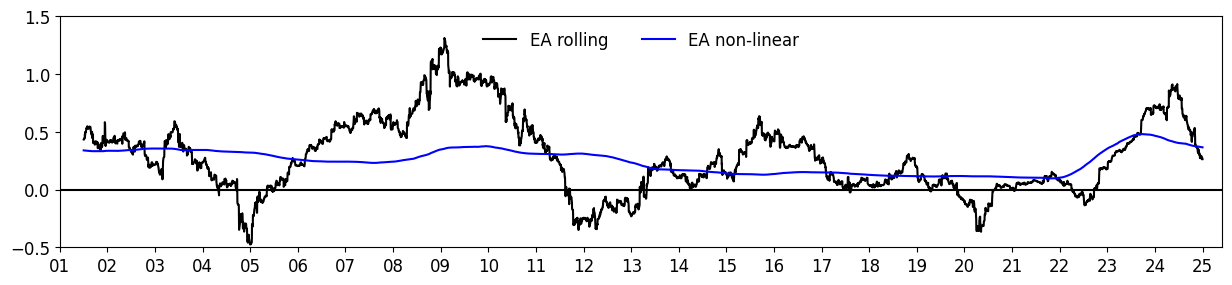

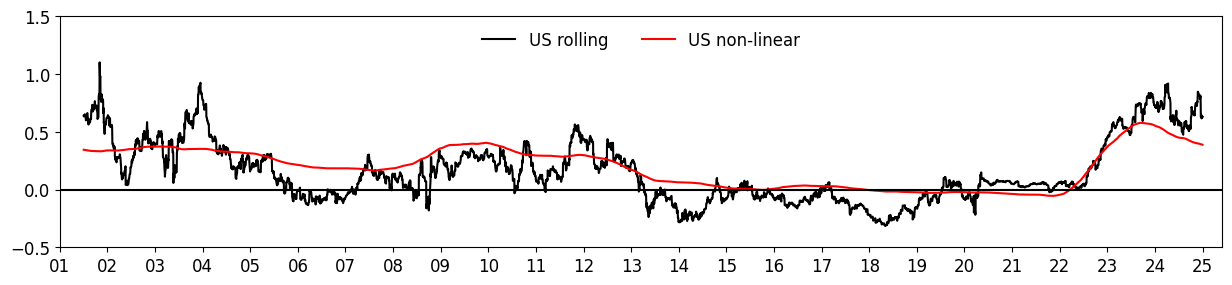

In [6]:
Z = pd.concat([uncertainty],axis=1)
Z.columns = ['Uncertainty']

def f(theta,phi_one,beta,Z):
    return (float(theta) + float(phi_one)*Z['Uncertainty']/100)*float(beta)
    
ff = f(df_params.loc[r'$\theta^{EA}$','Estimate'],df_params.loc[r'$\phi_1^{EA}$','Estimate'],df_params.loc[r'$\beta^{EA}$','Estimate'],Z)
gg = f(df_params.loc[r'$\theta^{US}$','Estimate'],df_params.loc[r'$\phi_1^{US}$','Estimate'],df_params.loc[r'$\beta^{US}$','Estimate'],Z)
ffma = f(df_params.loc[r'$\theta^{EA}$','Estimate'],df_params.loc[r'$\phi_1^{EA}$','Estimate'],df_params.loc[r'$\beta^{EA}$','Estimate'],Z.rolling(window=373).mean())
ggma = f(df_params.loc[r'$\theta^{US}$','Estimate'],df_params.loc[r'$\phi_1^{US}$','Estimate'],df_params.loc[r'$\beta^{US}$','Estimate'],Z.rolling(window=373).mean())

coeff_nls = pd.concat([ff,gg,ffma,ggma],axis=1)
coeff_nls.columns = ['EA_nls','US_nls','EA_ma','US_ma']
coeff_nls['Time'] = coeff_nls.index
coeff_nls

if rate_reg == 0:
    path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\ESTR6M_rolling'
if rate_reg == 1:
    path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\ESTR2Y_rolling'
if rate_reg == 2:
    path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\ESTR5Y_rolling'
if rate_reg == 3:
    path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\ESTR10Y_rolling'
rolling = pd.read_pickle(path)
rolling['Time'] = rolling.index

coeff = rolling.merge(coeff_nls,how='inner',on='Time')
coeff.set_index('Time',inplace=True,drop=True)
coeff.dropna(inplace=True)

fmt_major = mdates.YearLocator(1, month = 1, day = 1)
maxx = math.ceil(coeff.loc[:,['EA','US','EA_nls','US_nls']].max().max())
minn = math.floor(coeff.loc[:,['EA','US','EA_nls','US_nls']].min().min())

fig,ax = plt.subplots(1,1,figsize=(15,3))
ax.plot(coeff.index,coeff['EA'],color='k',label='EA rolling')
ax.plot(coeff.index,coeff['EA_ma'],color='blue',label=r'EA non-linear')
ax.axhline(0,color='k')
ax.legend(loc='upper center',frameon=False, shadow=False, ncol=2,fontsize=12)
ax.xaxis.set_major_locator(fmt_major)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.set_xlim([datetime(2001,1,1),datetime(2025,6,1)])
ax.set_ylim([-0.5,1.5])
if rate_reg == 0:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_EA_6M',bbox_inches='tight')
if rate_reg == 1:
  plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_EA_2Y',bbox_inches='tight')
if rate_reg == 2:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_EA_5Y',bbox_inches='tight')
if rate_reg == 3:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_EA_10Y',bbox_inches='tight')

fig,ax = plt.subplots(1,1,figsize=(15,3))
ax.plot(coeff.index,coeff['US'],color='k',label='US rolling')
ax.plot(coeff.index,coeff['US_ma'],color='red',label='US non-linear')
ax.axhline(0,color='k')
ax.legend(loc='upper center',frameon=False, shadow=False, ncol=2,fontsize=12)
ax.xaxis.set_major_locator(fmt_major)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y'))
ax.set_ylim([-0.5,1.5])
ax.set_xlim([datetime(2001,1,1),datetime(2025,6,1)])
if rate_reg == 0:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_US_6M',bbox_inches='tight')
if rate_reg == 1:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_US_2Y',bbox_inches='tight')
if rate_reg == 2:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_US_5Y',bbox_inches='tight')
if rate_reg == 3:
    plt.savefig(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output\SW_US_10Y',bbox_inches='tight')